# Per-leg Photo Selection

For each intersection, finds the best-matching photo for every approach leg.
Photos are pre-filtered by notebook 02 and loaded from `selected_photos_{IMAGE_MODE}.csv`.

Pan = 0 for all photos in this dataset (north-facing convention).

**Input files:**
- `data/processed/selected_photos_{IMAGE_MODE}.csv` — filtered photo list (from notebook 02); includes `image_id`, `filepath`, `x`, `y`, `Pan`
- `data/processed/intersections_stratified.gpkg` — intersections with stratum labels (from notebook 03)
- `data/processed/wegvakken_rotterdam_bst_merged.gpkg` — NWB road segments with merged junction IDs (from notebook 01)
- `data/processed/intensiteiten_rotterdam.csv` — Rotterdam-only intensity cache (from notebook 03, optional)

**Output files:**
- `data/processed/leg_photo_selection.csv` — one row per intersection-leg with best-matched photo. Includes `intensity_wvk` (vehicles/day on the approach segment), `WVK_ID`, and `neighbor_jte_id` when `USE_INTENSITY=True`.
- `data/processed/leg_photo_candidates.csv` — top-N ranked candidate photos per leg; feeds into `util_photo_export_list` for CV training export

**Depends on:** notebooks 00, 01, 02 and 03 must be run first.

**Coordinate system:** RD New (EPSG:28992) — throughout.

In [14]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Base project directory
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"

# --- Image mode ---
# Must match the IMAGE_MODE used when running notebook 02.
# "panorama"   : one 360° image per location — uses u_deg reprojection in notebook 07
# "directional": four shots per location — notebook 04 selects best direction, notebook 07 resizes/stitches
IMAGE_MODE = "directional"  # change to "directional" to process four-direction photos

# Input: selected photos from notebook 02 — already filtered to near-intersection photos.
# Filename reflects IMAGE_MODE so panorama and directional runs don't overwrite each other.
# Columns (panorama): image_id, filepath, x, y, Pan
# Columns (directional): image_id, filepath_front/back/left/right, heading_front/right/back/left, x, y, Pan
SELECTED_CSV = os.path.join(PROJECT_DIR, "data", "processed",
                             f"selected_photos_{IMAGE_MODE}.csv")

# Input: master photo index — used by the false-drop coverage check in section 7.
# Prefer the external HDD when connected; fall back to the local copy if not.
HDD_INDEX_PATH   = r"D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv"
LOCAL_INDEX_PATH = os.path.join(PROJECT_DIR, "data", "raw", "image_index.csv")
INDEX_PATH = HDD_INDEX_PATH if os.path.exists(HDD_INDEX_PATH) else LOCAL_INDEX_PATH

# Input: NWB road segments with merged junction IDs - output of notebook 01.
WEGVAKKEN_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst_merged.gpkg")

# Input: unfiltered Rotterdam gemeente roads - used only for debug visualisation.
WEGVAKKEN_UNFILTERED_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")

# Input: stratified intersections - output of notebook 03 (adds dim_type, dim_risk, dim_vri, dim_speed).
# Falls back to the plain merged file (notebook 01 output) if the stratified file does not exist yet.
_stratified = os.path.join(PROJECT_DIR, "data", "processed", "intersections_stratified.gpkg")
_fallback   = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
INTERSECTIONS_PATH = _stratified if os.path.exists(_stratified) else _fallback
print(f"Using intersections file: {os.path.basename(INTERSECTIONS_PATH)}")

# Input: Rotterdam-only intensity cache, created by notebook 03 (USE_INTENSITY=True).
INTENSITY_ROT_FILE = os.path.join(PROJECT_DIR, "data", "processed", "intensiteiten_rotterdam.csv")

# Output: one row per leg — the single best-matched photo per leg.
# Filename reflects IMAGE_MODE so panorama and directional runs don't overwrite each other.
OUTPUT_CSV = os.path.join(PROJECT_DIR, "data", "processed",
                          f"leg_photo_selection_{IMAGE_MODE}.csv")

# Output: top-N candidate photos per leg — used to build the full panorama export manifest.
# Filename reflects IMAGE_MODE so panorama and directional runs don't overwrite each other.
CANDIDATES_CSV = os.path.join(PROJECT_DIR, "data", "processed",
                              f"leg_photo_candidates_{IMAGE_MODE}.csv")

# --- Distance parameters (shared with notebooks 01 and 02) ---
# Imported from pipeline_config.py — change values there and re-run notebook 01
# to propagate updated max_dist_m / ideal_dist_m to the intersections .gpkg.
# This notebook reads those columns from the .gpkg — no re-run needed here after tuning.
_config_dir = os.path.join(PROJECT_DIR, "notebooks", "pipeline")
if _config_dir not in sys.path:
    sys.path.insert(0, _config_dir)
from pipeline_config import (
    FALLBACK_BUFFER_M,      # fallback outer radius when max_dist_m is missing from .gpkg
    IDEAL_PHOTO_DIST_BASE,  # base ideal distance — fallback for deduplication when ideal_dist_m absent
    MIN_DIST,               # minimum photo distance from intersection centre
    STITCH_THRESHOLD,       # angular threshold for stitching two directional cameras
)

# Fallback max distance when max_dist_m is missing from the intersections file.
# Should only trigger if notebook 01 hasn't been run yet.
MAX_DIST = FALLBACK_BUFFER_M

print(f"MIN_DIST={MIN_DIST}m  |  MAX_DIST fallback={MAX_DIST}m  |  STITCH_THRESHOLD={STITCH_THRESHOLD}°")

# How far a photo may be from the wegvak centreline and still count as "on that road".
ROAD_BUFFER_M = 3

# Maximum angular deviation (degrees) allowed when chaining the next segment.
BEARING_CHAIN_TOLERANCE = 45

# Half-width of the visualisation window around each intersection (metres)
VIZ_RADIUS = 80

# Number of ranked candidate photos to keep per leg in the CV export list.
TOP_N_CANDIDATES = 3

# Toggle: add intensity_wvk (vehicles/day) per approach leg from the Fileradar cache.
USE_INTENSITY = True

# --- Testing mode ---
# Set to a number (e.g. 50) to only process that many intersections - faster for testing
N_INTERSECTIONS = None

CRS_RD = "EPSG:28992"

Using intersections file: intersections_stratified.gpkg
MIN_DIST=5m  |  MAX_DIST fallback=55m  |  STITCH_THRESHOLD=1°


## 1. Load selected photos

Load the pre-filtered photo list written by notebook 02.
Pan is already included (= 0 for every row — north-facing convention),
so no separate metadata file is needed.

In [15]:
# Load the selected photos CSV (output of notebook 02).
# Pan is already included (= 0 for all rows — north-facing convention confirmed by data provider).
selected = pd.read_csv(SELECTED_CSV)
print(f"Selected photos loaded: {len(selected):,}")

# Pan = 0 for all photos in this dataset (north-facing convention).
# The column should be present, but add it explicitly as a fallback in case
# notebook 02 did not write it.
if "Pan" not in selected.columns:
    selected["Pan"] = 0
    print("Note: 'Pan' column missing from CSV — defaulted to 0 (north-facing convention).")

# Convert to GeoDataFrame using RD New coordinates from the CSV
photos_gdf = gpd.GeoDataFrame(
    selected,
    geometry=gpd.points_from_xy(selected["x"], selected["y"]),
    crs=CRS_RD
)

print(f"Photos with Pan angle: {photos_gdf['Pan'].notna().sum():,}")
photos_gdf[["image_id", "x", "y", "Pan"]].head()

Selected photos loaded: 101,609
Photos with Pan angle: 101,609


,image_id,x,y,Pan
0,1_00570,96475.157,437789.145,0.0
1,1_00571,96470.207,437789.806,0.0
2,1_00572,96465.258,437790.479,0.0
3,1_00573,96460.300,437791.171,0.0
4,1_00574,96455.361,437791.853,0.0


## 2. Load NWB data

Load intersections (from notebook 00) and the NWB wegvakken road segments.
The wegvakken are used to find which roads connect to each intersection and
in which direction.

In [16]:
# Load intersections - output of notebook 03 (with stratum labels) if it exists,
# or falls back to notebook 01 output. Restore JTE_ID as the index.
intersections = gpd.read_file(INTERSECTIONS_PATH)
intersections = intersections.set_index("JTE_ID")
print(f"Intersections loaded: {len(intersections):,}")

# Load preprocessed wegvakken â€” already filtered to Rotterdam gemeente-managed
# roads and relevant BST_CODE types (RB/ERF/HR) by notebooks 00 and 01.
# JTE_ID_BEG/JTE_ID_END reflect merged cluster IDs, consistent with intersections above.
print("Loading NWB wegvakken...")
wegvakken = gpd.read_file(WEGVAKKEN_PATH)

print(f"Wegvakken loaded: {len(wegvakken):,} segments")

# Load the pre-BST-filter dataset for debug visualisation only.
# This lets us distinguish between missing roads (prep issue) vs missing photos (coverage issue).
wegvakken_unfiltered = gpd.read_file(WEGVAKKEN_UNFILTERED_PATH)
print(f"Wegvakken unfiltered loaded: {len(wegvakken_unfiltered):,} segments")


Intersections loaded: 4,715
Loading NWB wegvakken...
Wegvakken loaded: 24,837 segments
Wegvakken unfiltered loaded: 40,115 segments


## 2b. Classify road segments as approaching / exiting

Using `RIJRICHTNG` (travel direction) and the junction role (BEG/END), classify each segment
connected to an intersection as:

| RIJRICHTNG | Junction role | Status |
|---|---|---|
| H (Heen: BEGâ†’END) | END | **approaching** â€” traffic arrives here |
| T (Terug: ENDâ†’BEG) | BEG | **approaching** â€” traffic arrives here |
| H | BEG | exiting â€” traffic leaves here |
| T | END | exiting â€” traffic leaves here |
| B (Both) | either | two-way |
| O / missing | either | unknown |

Computed for all junctions in the loaded `intersections` set.

In [17]:
# Build a long-form table of (WVK_ID, JTE_ID, junction_role, RIJRICHTNG, approach_status)
# for every segment-junction connection in the loaded intersection set.
# This records, for each road segment at each junction, whether traffic flows toward
# (approaching) or away from (exiting) the junction -- based on the NWB RIJRICHTNG attribute.

jte_ids_set = set(intersections.index)  # junctions we care about

# Each wegvak touches two junctions (BEG and END).
# Split into two rows -- one per endpoint -- so each connection can be classified independently.
beg_ap = wegvakken[["WVK_ID", "JTE_ID_BEG", "RIJRICHTNG"]].rename(columns={"JTE_ID_BEG": "JTE_ID"}).copy()
end_ap = wegvakken[["WVK_ID", "JTE_ID_END", "RIJRICHTNG"]].rename(columns={"JTE_ID_END": "JTE_ID"}).copy()
beg_ap["junction_role"] = "BEG"
end_ap["junction_role"] = "END"

conn_approach = pd.concat([beg_ap, end_ap], ignore_index=True)

# Keep only connections to junctions we process -- discards segments outside our intersection set
conn_approach = conn_approach[conn_approach["JTE_ID"].isin(jte_ids_set)].copy()

def classify_approach(rij, role):
    """Classify a segment-junction connection as approaching, exiting, two-way, or unknown.

    NWB RIJRICHTNG:
      H = Heen  -> traffic travels from JTE_ID_BEG toward JTE_ID_END
      T = Terug -> traffic travels from JTE_ID_END toward JTE_ID_BEG
      B = Both  -> bidirectional (no enforced direction)
      O / other -> unknown

    A segment is *approaching* a junction when traffic flows TOWARD it:
      H + END: traffic moves BEG->END, arrives at END junction  (approaching)
      T + BEG: traffic moves END->BEG, arrives at BEG junction  (approaching)
    """
    if   rij == "H" and role == "END": return "approaching"
    elif rij == "T" and role == "BEG": return "approaching"
    elif rij == "H" and role == "BEG": return "exiting"
    elif rij == "T" and role == "END": return "exiting"
    elif rij == "B":                   return "two-way"
    else:                              return "unknown"

conn_approach["approach_status"] = conn_approach.apply(
    lambda r: classify_approach(r["RIJRICHTNG"], r["junction_role"]), axis=1
)

print(f"Segment-junction connections classified: {len(conn_approach):,}")
print(conn_approach["approach_status"].value_counts())
print(f"\nDistinct junctions covered: {conn_approach['JTE_ID'].nunique():,} / {len(intersections):,}")

Segment-junction connections classified: 16,490
approach_status
two-way        8697
approaching    3900
exiting        3893
Name: count, dtype: int64

Distinct junctions covered: 4,715 / 4,715


## 2c. Get leg bearings and leg polygons

In [18]:
from shapely.ops import unary_union

def bearing_between(x1, y1, x2, y2):
    """Calculate compass bearing from point (x1,y1) to point (x2,y2) in RD New.
    Returns degrees 0-360 where 0=North, 90=East (clockwise)."""
    dx = x2 - x1
    dy = y2 - y1
    return np.degrees(np.arctan2(dx, dy)) % 360


def get_leg_bearings(intersection_jte_id, wegvakken_gdf, intersections_gdf):
    """For a given NWB junction, return the bearing of each connected road leg.

    For each wegvak (road segment) that starts or ends at this junction,
    we find the coordinate of the OTHER endpoint and calculate the bearing
    from there toward the intersection -- this is the approach bearing for that leg.

    For FOW=2 (dual carriageway) segments, RIJRICHTNG is used to discard the
    exiting lane before any other checks run. This replaces the old RPE_CODE-based
    dedup, which was too naive (RPE_CODE L/R and compass values can't be compared
    reliably across road types).

    NWB coordinates are already in RD New, so no reprojection is needed.
    """
    legs = []

    # Get the intersection's RD New coordinates from the intersections GeoDataFrame
    node = intersections_gdf.loc[intersection_jte_id]
    ix, iy = node.geometry.x, node.geometry.y

    # Find all wegvakken that connect to this junction (as start OR end point)
    connected = wegvakken_gdf[
        (wegvakken_gdf["JTE_ID_BEG"] == intersection_jte_id) |
        (wegvakken_gdf["JTE_ID_END"] == intersection_jte_id)
    ]

    seen_bearings = []  # bearing-based dedup: catches two-way roads digitized twice

    for _, wvk in connected.iterrows():
        # Determine junction role: is this intersection at the BEG or END of the segment?
        # This tells us the direction of traffic flow relative to the junction.
        if wvk["JTE_ID_BEG"] == intersection_jte_id:
            junction_role  = "BEG"
            neighbor_coord = wvk.geometry.coords[-1]  # intersection at start -> take end
            neighbor_jte   = wvk["JTE_ID_END"]
        else:
            junction_role  = "END"
            neighbor_coord = wvk.geometry.coords[0]   # intersection at end -> take start
            neighbor_jte   = wvk["JTE_ID_BEG"]

        # FOW=2 filter: skip the exiting lane of dual carriageways.
        # RIJRICHTNG=H means traffic flows BEG->END; T means END->BEG.
        # A segment exits the intersection when traffic flows AWAY from the junction:
        #   H + BEG role: traffic leaves from the junction (BEG) toward END -> exiting
        #   T + END role: traffic leaves from the junction (END) toward BEG -> exiting
        # RIJRICHTNG=B (bidirectional) and O (unknown) are kept -- cannot classify.
        if str(wvk.get("FOW", "")) == "2":
            rij = str(wvk.get("RIJRICHTNG", "") or "")
            if (rij == "H" and junction_role == "BEG") or (rij == "T" and junction_role == "END"):
                continue  # this lane exits the intersection -- skip

        # NWB is already in RD New -- no coordinate reprojection needed
        nx_rd, ny_rd = neighbor_coord[0], neighbor_coord[1]

        # Bearing FROM neighbor TO intersection = approach bearing for this leg
        approach_bearing = bearing_between(nx_rd, ny_rd, ix, iy)

        # Skip near-duplicate bearings -- catches two-way roads digitized as two segments
        if any(abs((approach_bearing - b + 180) % 360 - 180) < 30 for b in seen_bearings):
            continue

        seen_bearings.append(approach_bearing)
        legs.append({
            "intersection_id": intersection_jte_id,
            "inter_x":         ix,
            "inter_y":         iy,
            "leg_bearing":     round(approach_bearing, 1),
            "neighbor_jte_id": neighbor_jte,
        })

    return legs


def chain_segments_for_leg(intersection_jte_id, leg_bearing, wegvakken_gdf,
                            max_dist=MAX_DIST,
                            bearing_tolerance=BEARING_CHAIN_TOLERANCE):
    """Walk the NWB graph outward from an intersection along one leg direction,
    greedily chaining segments that continue in roughly the same bearing.

    At each junction encountered along the way, the next segment is chosen as
    the one whose travel bearing deviates least from the current direction, as
    long as it is within bearing_tolerance degrees. The bearing is updated after
    each segment so that gradual road curves are followed naturally.

    Stops when cumulative length >= max_dist or no qualifying segment is found.
    This handles short wegvakken near complex intersections by following the road
    further rather than stopping after the first (possibly very short) stub.

    Returns a list of Shapely geometries forming the corridor along this leg.
    """
    # Convert from approach bearing (toward intersection) to outgoing bearing (away)
    outgoing_bearing = (leg_bearing + 180) % 360

    cumulative_length = 0.0
    chained_geoms     = []
    visited_junctions = {intersection_jte_id}  # prevent backtracking
    current_jte_id    = intersection_jte_id
    current_bearing   = outgoing_bearing

    while cumulative_length < max_dist:
        # Find all segments connected to the current junction
        connected = wegvakken_gdf[
            (wegvakken_gdf["JTE_ID_BEG"] == current_jte_id) |
            (wegvakken_gdf["JTE_ID_END"] == current_jte_id)
        ]

        best_seg          = None
        best_diff         = bearing_tolerance  # only accept segments within tolerance
        best_next_jte     = None
        best_next_bearing = None

        for _, seg in connected.iterrows():
            # Determine traversal direction: always move away from current junction
            if seg["JTE_ID_BEG"] == current_jte_id:
                next_jte = seg["JTE_ID_END"]
                c0, c1   = seg.geometry.coords[0], seg.geometry.coords[-1]
            else:
                next_jte = seg["JTE_ID_BEG"]
                c0, c1   = seg.geometry.coords[-1], seg.geometry.coords[0]

            # Skip already-visited junctions to avoid backtracking
            if next_jte in visited_junctions:
                continue

            # FOW=2 filter: skip exiting lanes during chaining.
            # Same RIJRICHTNG logic as in get_leg_bearings() -- prevents the chain
            # from following the parallel exiting carriageway instead of the
            # approaching one (both run in the same bearing, so bearing alone
            # cannot distinguish them).
            if str(seg.get("FOW", "")) == "2":
                rij  = str(seg.get("RIJRICHTNG", "") or "")
                role = "BEG" if seg["JTE_ID_BEG"] == current_jte_id else "END"
                if (rij == "H" and role == "BEG") or (rij == "T" and role == "END"):
                    continue  # exiting lane -- skip

            # Bearing of travel along this segment (away from current junction)
            seg_bearing = bearing_between(c0[0], c0[1], c1[0], c1[1])
            diff = abs((seg_bearing - current_bearing + 180) % 360 - 180)

            # Keep the candidate closest to the current travel direction
            if diff < best_diff:
                best_diff         = diff
                best_seg          = seg
                best_next_jte     = next_jte
                best_next_bearing = seg_bearing

        if best_seg is None:
            break  # dead end or all continuations deviate too much

        chained_geoms.append(best_seg.geometry)
        cumulative_length += best_seg.geometry.length
        visited_junctions.add(best_next_jte)
        current_jte_id  = best_next_jte
        current_bearing = best_next_bearing  # update direction to follow road curvature

    return chained_geoms


# Limit to N_INTERSECTIONS for testing -- use all if N_INTERSECTIONS is None
ids_to_process = intersections.index[:N_INTERSECTIONS] if N_INTERSECTIONS else intersections.index
print(f"Extracting leg bearings for {len(ids_to_process)} intersections...")

all_legs = []
for i, jte_id in enumerate(ids_to_process):
    all_legs.extend(get_leg_bearings(jte_id, wegvakken, intersections))
    if (i + 1) % 500 == 0 or (i + 1) == len(ids_to_process):
        print(f"  {i+1}/{len(ids_to_process)} intersections done")

legs_df = pd.DataFrame(all_legs)

# Join per-intersection capture distance from intersections (computed in notebook 01).
# max_dist_m = (cluster_diameter / 2) + CAPTURE_BUFFER_M, so large intersections
# get a wider search radius while singletons keep the default 30 m.
legs_df = legs_df.merge(
    intersections[["max_dist_m", "ideal_dist_m"]],
    left_on="intersection_id", right_index=True,
    how="left",
)
print(f"\nTotal legs extracted: {len(legs_df):,}")
print(f"Average legs per intersection: {len(legs_df)/len(ids_to_process):.1f}")

# Build a per-leg road buffer using bearing-guided segment chaining.
# For each leg, chain segments outward from the intersection along the leg's direction
# until MAX_DIST is covered. Then buffer the resulting geometry by ROAD_BUFFER_M.
# Stores both the buffer polygon (for Filter 3) and the raw chain geometries (for viz).
print(f"\nComputing per-leg road buffers (bearing-guided chaining, tolerance={BEARING_CHAIN_TOLERANCE}Â°)...")
leg_buffers         = []
leg_chains          = []
leg_direct_segments = []  # directly connected segments, kept separately for viz

for _, leg_row in legs_df.iterrows():
    jte_id = leg_row["intersection_id"]

    # Directly connected segments for this intersection -- used for viz layer
    direct = wegvakken[
        (wegvakken["JTE_ID_BEG"] == jte_id) |
        (wegvakken["JTE_ID_END"] == jte_id)
    ]
    leg_direct_segments.append(direct)

    # Chain outward along the leg's bearing direction
    chain_geoms = chain_segments_for_leg(jte_id, leg_row["leg_bearing"], wegvakken, max_dist=leg_row["max_dist_m"])
    leg_chains.append(chain_geoms)

    if chain_geoms:
        # Buffer the union of all chained segment geometries for this leg
        union_geom = unary_union(chain_geoms)
        leg_buffers.append(union_geom.buffer(ROAD_BUFFER_M))
    else:
        # Fallback: buffer directly connected segments if chaining found nothing
        union_geom = unary_union(direct.geometry.values)
        leg_buffers.append(union_geom.buffer(ROAD_BUFFER_M))

legs_df["road_buffer_geom"]  = leg_buffers         # Shapely polygon per leg -- used by Filter 3
legs_df["chained_geoms"]     = leg_chains           # list of LineStrings -- chained corridor
print(f"Per-leg road buffers computed for {len(legs_df)} legs")

legs_df.drop(columns=["road_buffer_geom", "chained_geoms"]).head(10)  # hide geometry for display

Extracting leg bearings for 4715 intersections...
  500/4715 intersections done
  1000/4715 intersections done
  1500/4715 intersections done
  2000/4715 intersections done
  2500/4715 intersections done
  3000/4715 intersections done
  3500/4715 intersections done
  4000/4715 intersections done
  4500/4715 intersections done
  4715/4715 intersections done

Total legs extracted: 13,957
Average legs per intersection: 3.0

Computing per-leg road buffers (bearing-guided chaining, tolerance=45Â°)...
Per-leg road buffers computed for 13957 legs


,intersection_id,inter_x,inter_y,leg_bearing,neighbor_jte_id,max_dist_m,ideal_dist_m
0,187268127,93790.957936,434221.042064,139.2,187268045,25.8,20.8
1,187268127,93790.957936,434221.042064,318.8,187268130,25.8,20.8
2,187268127,93790.957936,434221.042064,261.8,187268038,25.8,20.8
3,187268127,93790.957936,434221.042064,51.2,187268042,25.8,20.8
4,187268073,93610.936880,434444.810010,197.3,187269085,25.0,20.0
5,187268073,93610.936880,434444.810010,18.2,187268072,25.0,20.0
6,187268073,93610.936880,434444.810010,287.7,187268075,25.0,20.0
7,192266029,96195.904349,433030.381519,241.5,192266039,25.0,20.0
8,192266029,96195.904349,433030.381519,152.4,192266028,25.0,20.0
9,192266029,96195.904349,433030.381519,61.4,192265008,25.0,20.0


## 3. Match photos to intersection legs

In [19]:
from shapely.geometry import Point

# Clockwise order of the 4 directional cameras.
# Used to find the adjacent camera for stitching: the neighbour that brings
# the intersection closer to center is one step clockwise or counter-clockwise.
DIRECTION_ORDER = ["front", "right", "back", "left"]


def _pick_stitch_direction(selected_dir, angle_offset):
    """Return the adjacent camera direction to stitch with the selected one.

    angle_offset is the signed angular difference: bearing_to_inter - heading_selected,
    normalised to [-180, 180]. Positive = intersection is to the right of the camera
    centre, so the right neighbour (clockwise) closes the gap; negative = left neighbour.
    """
    idx = DIRECTION_ORDER.index(selected_dir)
    if angle_offset >= 0:
        # Intersection to the right — stitch selected + clockwise neighbour
        return DIRECTION_ORDER[(idx + 1) % 4]
    else:
        # Intersection to the left — stitch counter-clockwise neighbour + selected
        return DIRECTION_ORDER[(idx - 1) % 4]


def _directional_extra_fields(photo, bearing_to_inter):
    """Compute directional-mode columns for one matched photo.

    Returns a dict of extra fields to merge into the result row:
      - is_panorama          : False
      - selected_direction   : which camera faces closest to the intersection
      - photo_filepath       : path for the selected camera direction
      - filepath_front/back/left/right : all four camera paths (stored for nb07)
      - requires_stitch      : True when the intersection is > STITCH_THRESHOLD off-centre
      - stitch_left_filepath : left image in the stitched pair (when requires_stitch)
      - stitch_right_filepath: right image in the stitched pair (when requires_stitch)
      - stitch_inter_col_frac: [0,1] position of the intersection in the stitched image
    """
    # For each camera direction, compute how far off-centre the intersection falls.
    # heading_* is the compass bearing the camera faces; a small angle_diff means
    # the intersection is nearly straight ahead in that camera.
    diffs = {}
    for d in DIRECTION_ORDER:
        heading = photo[f"heading_{d}"]
        diffs[d] = abs((bearing_to_inter - heading + 180) % 360 - 180)

    selected_dir = min(diffs, key=diffs.get)
    min_diff     = diffs[selected_dir]

    # All four filepaths — stored in the output CSV so notebook 07 can access any of them
    fp = {f"filepath_{d}": photo[f"filepath_{d}"] for d in DIRECTION_ORDER}

    # Signed offset: positive = intersection is clockwise from camera centre
    selected_heading = photo[f"heading_{selected_dir}"]
    angle_offset = (bearing_to_inter - selected_heading + 180) % 360 - 180

    requires_stitch = min_diff > STITCH_THRESHOLD

    extra = {
        "is_panorama":        False,
        "selected_direction": selected_dir,
        "photo_filepath":     photo[f"filepath_{selected_dir}"],
        **fp,
        "requires_stitch":    requires_stitch,
    }

    if requires_stitch:
        # Find the adjacent camera that closes the angular gap
        stitch_dir = _pick_stitch_direction(selected_dir, angle_offset)

        # Arrange left/right in clockwise order so nb07 stitches them correctly
        sel_idx    = DIRECTION_ORDER.index(selected_dir)
        stitch_idx = DIRECTION_ORDER.index(stitch_dir)
        if (stitch_idx - sel_idx) % 4 == 1:
            # stitch_dir is clockwise from selected → selected=left, stitch=right
            left_dir, right_dir = selected_dir, stitch_dir
        else:
            # stitch_dir is counter-clockwise from selected → stitch=left, selected=right
            left_dir, right_dir = stitch_dir, selected_dir

        # inter_col_frac: where the intersection lands in the 2-camera stitched image.
        # Each camera is 90° wide. In the stitched image the left camera occupies [0, 0.5]
        # and the right camera [0.5, 1.0]. The intersection is at angle_offset degrees
        # from the selected camera's centre; convert to a fraction of the 180° stitched FOV.
        left_heading = photo[f"heading_{left_dir}"]
        offset_in_stitched = (bearing_to_inter - left_heading + 180) % 360 - 180
        inter_col_frac = np.clip((offset_in_stitched + 90) / 180, 0, 1)

        extra["stitch_left_filepath"]  = photo[f"filepath_{left_dir}"]
        extra["stitch_right_filepath"] = photo[f"filepath_{right_dir}"]
        extra["stitch_inter_col_frac"] = round(float(inter_col_frac), 4)
    else:
        extra["stitch_left_filepath"]  = None
        extra["stitch_right_filepath"] = None
        extra["stitch_inter_col_frac"] = None

    return extra


def assign_photo_to_leg(leg_row, photos_gdf, min_dist=MIN_DIST, max_dist=MAX_DIST, ideal_dist=IDEAL_PHOTO_DIST_BASE):
    """For a single leg, find and rank all matching photos sorted by proximity to ideal distance.

    Strategy:
    1. Find all photos within max_dist of the intersection
    2. Filter to photos approaching from roughly the right direction (within 45 degrees)
    3. Filter to photos that lie inside the road buffer polygon -- a ROAD_BUFFER_M-wide
       corridor built by bearing-guided chaining of wegvakken along this specific leg.
       This rejects photos on nearby parallel roads and handles short stubs near
       complex junctions by extending the corridor until MAX_DIST is covered.
    4. Sort all remaining candidates by proximity to the ideal approach distance (~30m)

    Returns a list of dicts sorted best-first (rank 1 = best), or an empty list if no
    suitable photos found. The first element is equivalent to the old single-best result;
    subsequent elements are runner-ups for CV training diversity.

    For panorama mode: sets is_panorama=True, stores a single filepath and u_deg.
    For directional mode: selects the best camera direction, stores all four filepaths,
    and computes stitch columns when the intersection falls > STITCH_THRESHOLD off-centre.
    """
    ix, iy           = leg_row["inter_x"], leg_row["inter_y"]
    leg_bearing      = leg_row["leg_bearing"]
    road_buffer_geom = leg_row["road_buffer_geom"]  # per-leg chained corridor polygon

    # Calculate distance and bearing from each photo to this intersection
    dx = ix - photos_gdf["x"].values
    dy = iy - photos_gdf["y"].values
    dist = np.sqrt(dx**2 + dy**2)

    # Bearing from each photo toward the intersection
    bearing_to_inter = np.degrees(np.arctan2(dx, dy)) % 360

    # Filter 1: distance to intersection -- must be between min and max
    dist_mask = (dist >= min_dist) & (dist <= max_dist)

    # Filter 2: approach direction -- photo must be on this leg's side of the intersection.
    # leg_bearing is the bearing FROM the road neighbor TOWARD the intersection, so a
    # photo correctly placed on this leg should have bearing_to_inter ~= leg_bearing.
    approach_dir = leg_bearing
    angle_diff = np.abs((bearing_to_inter - approach_dir + 180) % 360 - 180)
    dir_mask = angle_diff <= 45

    candidates = photos_gdf[dist_mask & dir_mask].copy()
    if len(candidates) == 0:
        return []

    # Filter 3: road buffer -- photo must lie inside the per-leg chained corridor polygon.
    # The corridor follows actual road geometry, handles curves, and is guaranteed to
    # extend at least MAX_DIST from the intersection via bearing-guided chaining.
    road_mask = np.array([
        road_buffer_geom.contains(Point(x, y))
        for x, y in zip(candidates["x"], candidates["y"])
    ])
    candidates = candidates[road_mask]
    if len(candidates) == 0:
        return []

    # Slice distance and bearing arrays to stay aligned with the filtered candidates index
    candidate_dists = pd.Series(dist[dist_mask & dir_mask][road_mask], index=candidates.index)
    bearing_series  = pd.Series(bearing_to_inter[dist_mask & dir_mask][road_mask], index=candidates.index)

    # Sort all candidates by proximity to ideal distance -- best first.
    # Element [0] is the best match for the pipeline; elements [1..N-1] are runner-ups
    # available for CV training diversity.
    sorted_indices = (candidate_dists - ideal_dist).abs().sort_values().index

    result_list = []
    for rank, idx in enumerate(sorted_indices, start=1):
        photo       = candidates.loc[idx]
        dist_val    = candidate_dists.loc[idx]
        bearing_val = bearing_series.loc[idx]

        # Base fields common to both image modes
        row = {
            "intersection_id":        leg_row["intersection_id"],
            "leg_bearing":            leg_bearing,
            "photo_filename":         photo["image_id"],
            "photo_dist_m":           round(dist_val, 1),
            "u_deg":                  round((bearing_val - photo["Pan"] + 180) % 360 - 180, 1),
            "photo_x":                photo["x"],
            "photo_y":                photo["y"],
            "photo_bearing_to_inter": round(bearing_val, 1),
            "candidate_rank":         rank,
        }

        if IMAGE_MODE == "panorama":
            # Panorama: single 360° image, u_deg rotation centres the intersection
            row["photo_filepath"] = photo["filepath"]
            row["is_panorama"]    = True
        else:
            # Directional: pick the best camera direction and compute stitch columns
            row.update(_directional_extra_fields(photo, bearing_val))

        result_list.append(row)

    return result_list


# Run matching for all legs.
# results        -> top-1 per leg, feeds into the pipeline CSV (leg_photo_selection.csv)
# all_candidates -> top-N per leg, feeds into the CV export CSV (leg_photo_candidates.csv)
print("Matching photos to legs...")
results        = []
all_candidates = []
for i, (_, leg_row) in enumerate(legs_df.iterrows()):
    ranked = assign_photo_to_leg(
        leg_row, photos_gdf,
        max_dist=leg_row["max_dist_m"],
        ideal_dist=leg_row["ideal_dist_m"],
    )
    if ranked:
        results.append(ranked[0])                         # best only -> pipeline
        all_candidates.extend(ranked[:TOP_N_CANDIDATES])  # top-N    -> export list

    if (i + 1) % 2000 == 0 or (i + 1) == len(legs_df):
        pct = (i + 1) / len(legs_df) * 100
        print(f"  {i+1}/{len(legs_df)} legs done ({pct:.0f}%) -- {len(results)} matches so far")

result_df = pd.DataFrame(results)
pre_dedup = len(result_df)

# Post-match deduplication: within each intersection, if two matched photos have
# nearly the same bearing_to_inter (within 20 degrees), they look at the intersection
# from the same direction and one is redundant. Keep the photo closest to ideal distance.
# Note: deduplication applies only to result_df (the pipeline CSV), not all_candidates.
DEDUP_BEARING_THRESH = 20
kept_rows = []
for inter_id, group in result_df.groupby("intersection_id"):
    group = group.iloc[(group["photo_dist_m"] - group.get("ideal_dist_m", IDEAL_PHOTO_DIST_BASE)).abs().argsort()]
    seen_post = []
    for _, row in group.iterrows():
        b = row["photo_bearing_to_inter"]
        if any(abs((b - sb + 180) % 360 - 180) < DEDUP_BEARING_THRESH for sb in seen_post):
            continue
        seen_post.append(b)
        kept_rows.append(row)

result_df = pd.DataFrame(kept_rows).reset_index(drop=True)
print(f"Legs with a matched photo (before dedup): {pre_dedup:,} / {len(legs_df):,}")
print(f"After bearing deduplication:              {len(result_df):,}")
print(f"Coverage: {len(result_df)/len(legs_df)*100:.1f}%")
result_df.head(10)

Matching photos to legs...
  2000/13957 legs done (14%) -- 1799 matches so far
  4000/13957 legs done (29%) -- 3664 matches so far
  6000/13957 legs done (43%) -- 5461 matches so far
  8000/13957 legs done (57%) -- 7277 matches so far
  10000/13957 legs done (72%) -- 9121 matches so far
  12000/13957 legs done (86%) -- 10939 matches so far
  13957/13957 legs done (100%) -- 12709 matches so far
Legs with a matched photo (before dedup): 12,709 / 13,957
After bearing deduplication:              12,677
Coverage: 90.8%


,intersection_id,leg_bearing,photo_filename,photo_dist_m,u_deg,photo_x,photo_y,photo_bearing_to_inter,candidate_rank,is_panorama,selected_direction,photo_filepath,filepath_front,filepath_right,filepath_back,filepath_left,requires_stitch,stitch_left_filepath,stitch_right_filepath,stitch_inter_col_frac
0,175268012,194.7,364_03023,19.7,-160.3,87950.010,434162.853,199.7,1,False,back,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,True,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,0.5354
1,175268012,110.0,364_02717,19.4,109.6,87925.094,434150.823,109.6,1,False,back,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,False,NaN,NaN,NaN
2,175268012,299.8,364_02709,20.6,-69.3,87962.624,434137.018,290.7,1,False,front,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,False,NaN,NaN,NaN
3,175268013,119.8,364_02986,19.8,109.4,87936.207,434144.273,109.4,1,False,front,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,False,NaN,NaN,NaN
4,175268013,21.6,364_03014,19.8,16.7,87949.209,434118.793,16.7,1,False,front,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,True,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,0.9831
5,175268013,289.7,364_02707,17.6,-76.2,87971.995,434133.521,283.8,1,False,front,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,True,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,0.9656
6,175272033,155.4,18_01652,19.4,151.6,87929.242,436056.034,151.6,1,False,front,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,True,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,88196ba207fffff/89196ba206fffff/8a196ba206f7ff...,0.9824
7,175272033,337.0,18_01702,19.3,-31.2,87948.488,436022.451,328.8,1,False,front,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,True,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,88196ba207fffff/89196ba206fffff/8a196ba206d7ff...,0.9672
8,175273001,106.9,18_01544,21.9,106.1,87959.557,436535.474,106.1,1,False,front,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,True,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,88196ba207fffff/89196ba207bffff/8a196ba20787ff...,0.9908
9,1752730

## 4. Coverage analysis - how many legs per intersection have a photo?

Coverage summary:
count    4715.000000
mean       90.676564
std        20.797743
min         0.000000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: coverage_pct, dtype: float64

Intersections with all legs covered: 3,741
Intersections with no coverage:      100


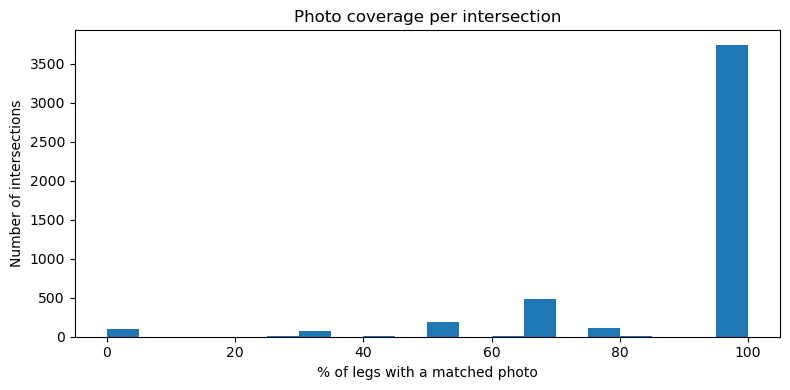

In [20]:
# Count how many legs per intersection have a matched photo
legs_per_inter    = legs_df.groupby("intersection_id").size().rename("total_legs")
matched_per_inter = result_df.groupby("intersection_id").size().rename("matched_legs")

coverage = pd.concat([legs_per_inter, matched_per_inter], axis=1).fillna(0)
coverage["matched_legs"] = coverage["matched_legs"].astype(int)
coverage["coverage_pct"] = (coverage["matched_legs"] / coverage["total_legs"] * 100).round(1)

print("Coverage summary:")
print(coverage["coverage_pct"].describe())
print(f"\nIntersections with all legs covered: {(coverage['coverage_pct']==100).sum():,}")
print(f"Intersections with no coverage:      {(coverage['matched_legs']==0).sum():,}")

# Histogram of coverage per intersection
fig, ax = plt.subplots(figsize=(8, 4))
coverage["coverage_pct"].plot.hist(bins=20, ax=ax)
ax.set_xlabel("% of legs with a matched photo")
ax.set_ylabel("Number of intersections")
ax.set_title("Photo coverage per intersection")
plt.tight_layout()
plt.show()

## 4b. Photo distance distribution

How far are the matched photos from the intersection? Checks whether the very short
matches seen in the preview (e.g. 9m, 14m) are edge cases or a structural pattern.

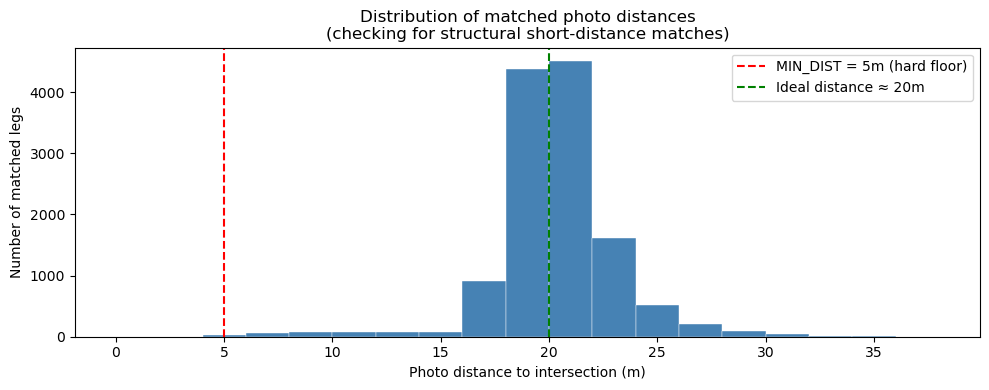

Photo distance stats (all 12,677 matched legs):
count    12677.0
mean        20.3
std          2.8
min          5.0
5%          17.6
10%         17.9
25%         18.8
50%         20.2
75%         21.6
90%         22.7
95%         24.8
max         37.9
Name: photo_dist_m, dtype: float64

Legs per distance band:
   5–15m :   353  (2.8%)
  15–20m : 5,325  (42.0%)
  20–30m : 6,932  (54.7%)
  30–40m :    67  (0.5%)
  40–55m :     0  (0.0%)


In [21]:
# Distribution of matched photo distances — checking whether very short matches
# (e.g. 9m, 14m) are incidental or structural.
# MIN_DIST is the hard floor; IDEAL_PHOTO_DIST_BASE is the sorting target in assign_photo_to_leg().
fig, ax = plt.subplots(figsize=(10, 4))

# 2m bins across the full observed range
bins = np.arange(0, result_df["photo_dist_m"].max() + 2, 2)
ax.hist(result_df["photo_dist_m"], bins=bins, edgecolor="white", linewidth=0.3, color="steelblue")

# Reference lines so the chart is self-explanatory
ax.axvline(MIN_DIST, color="red", linestyle="--", linewidth=1.5,
           label=f"MIN_DIST = {MIN_DIST}m (hard floor)")
ax.axvline(IDEAL_PHOTO_DIST_BASE, color="green", linestyle="--", linewidth=1.5,
           label=f"Ideal distance ≈ {IDEAL_PHOTO_DIST_BASE}m")

ax.set_xlabel("Photo distance to intersection (m)")
ax.set_ylabel("Number of matched legs")
ax.set_title("Distribution of matched photo distances\n(checking for structural short-distance matches)")
ax.legend()
plt.tight_layout()
plt.show()

# Quantify how many legs fall in each distance band for easy interpretation
print(f"Photo distance stats (all {len(result_df):,} matched legs):")
print(result_df["photo_dist_m"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(1))

print("\nLegs per distance band:")
bands = [(MIN_DIST, 15), (15, 20), (20, 30), (30, 40), (40, 55)]
for lo, hi in bands:
    n = ((result_df["photo_dist_m"] >= lo) & (result_df["photo_dist_m"] < hi)).sum()
    print(f"  {lo:2d}–{hi:2d}m : {n:5,}  ({n/len(result_df)*100:.1f}%)")

In [22]:
# --- Investigate short-distance matches ---
# "Short" = photo_dist_m < 20m (well below the 25m ideal).
# Goal: understand WHY these photos get selected — is it because no farther photo
# exists on this leg, or is the road buffer / bearing filter cutting too aggressively?

SHORT_THRESH = 20  # metres — adjust to move the definition of "short"

short = result_df[result_df["photo_dist_m"] < SHORT_THRESH].copy()
normal = result_df[result_df["photo_dist_m"] >= SHORT_THRESH].copy()
print(f"Short-distance matches (< {SHORT_THRESH}m): {len(short):,}  ({len(short)/len(result_df)*100:.1f}%)")
print(f"Normal matches (≥ {SHORT_THRESH}m):         {len(normal):,}  ({len(normal)/len(result_df)*100:.1f}%)\n")

# 1. Are short matches concentrated in certain intersection types?
# Merge with intersection metadata (dim_type, dim_risk, etc.)
short_meta = short.merge(
    intersections[["dim_type", "dim_risk", "dim_speed", "max_dist_m", "ideal_dist_m", "diameter_m"]],
    left_on="intersection_id", right_index=True, how="left"
)
normal_meta = normal.merge(
    intersections[["dim_type", "dim_risk", "dim_speed", "max_dist_m", "ideal_dist_m", "diameter_m"]],
    left_on="intersection_id", right_index=True, how="left"
)

print("--- dim_type distribution ---")
type_short  = short_meta["dim_type"].value_counts(normalize=True).rename("short %") * 100
type_normal = normal_meta["dim_type"].value_counts(normalize=True).rename("normal %") * 100
print(pd.concat([type_short, type_normal], axis=1).round(1).to_string())

print("\n--- ideal_dist_m for short vs normal matches ---")
print(f"Short  — mean ideal_dist_m: {short_meta['ideal_dist_m'].mean():.1f}m, "
      f"median: {short_meta['ideal_dist_m'].median():.1f}m")
print(f"Normal — mean ideal_dist_m: {normal_meta['ideal_dist_m'].mean():.1f}m, "
      f"median: {normal_meta['ideal_dist_m'].median():.1f}m")

# 2. For each short-distance match, how many candidates existed at normal distance?
# Re-use all_candidates (top-3 per leg before dedup) to check whether a farther
# candidate existed but was ranked lower.
cand_df = pd.DataFrame(all_candidates)
short_ids = set(zip(short["intersection_id"], short["leg_bearing"]))

# For every short best-match, was a normal-distance candidate also available?
normal_cands_for_short = cand_df[
    cand_df.apply(lambda r: (r["intersection_id"], r["leg_bearing"]) in short_ids, axis=1)
    & (cand_df["photo_dist_m"] >= SHORT_THRESH)
]
legs_with_normal_alt = normal_cands_for_short[["intersection_id", "leg_bearing"]].drop_duplicates()

print(f"\n--- Were farther candidates available for short-matched legs? ---")
print(f"Short-matched legs:                        {len(short):,}")
print(f"Of those with a ≥{SHORT_THRESH}m candidate in top-3:  {len(legs_with_normal_alt):,}  "
      f"({len(legs_with_normal_alt)/len(short)*100:.1f}%)")
print(f"No farther candidate at all (truly coverage-limited): "
      f"{len(short) - len(legs_with_normal_alt):,}  "
      f"({(len(short)-len(legs_with_normal_alt))/len(short)*100:.1f}%)")

Short-distance matches (< 20m): 5,678  (44.8%)
Normal matches (≥ 20m):         6,999  (55.2%)

--- dim_type distribution ---
          short %  normal %
dim_type                   
T            76.9      61.2
4+           23.1      38.8

--- ideal_dist_m for short vs normal matches ---
Short  — mean ideal_dist_m: 20.1m, median: 20.0m
Normal — mean ideal_dist_m: 21.0m, median: 20.0m

--- Were farther candidates available for short-matched legs? ---
Short-matched legs:                        5,678
Of those with a ≥20m candidate in top-3:  5,066  (89.2%)
No farther candidate at all (truly coverage-limited): 612  (10.8%)


## 5. Visualise - spot check a single intersection

Using full_df from section 7 (617,579 photos total)


C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


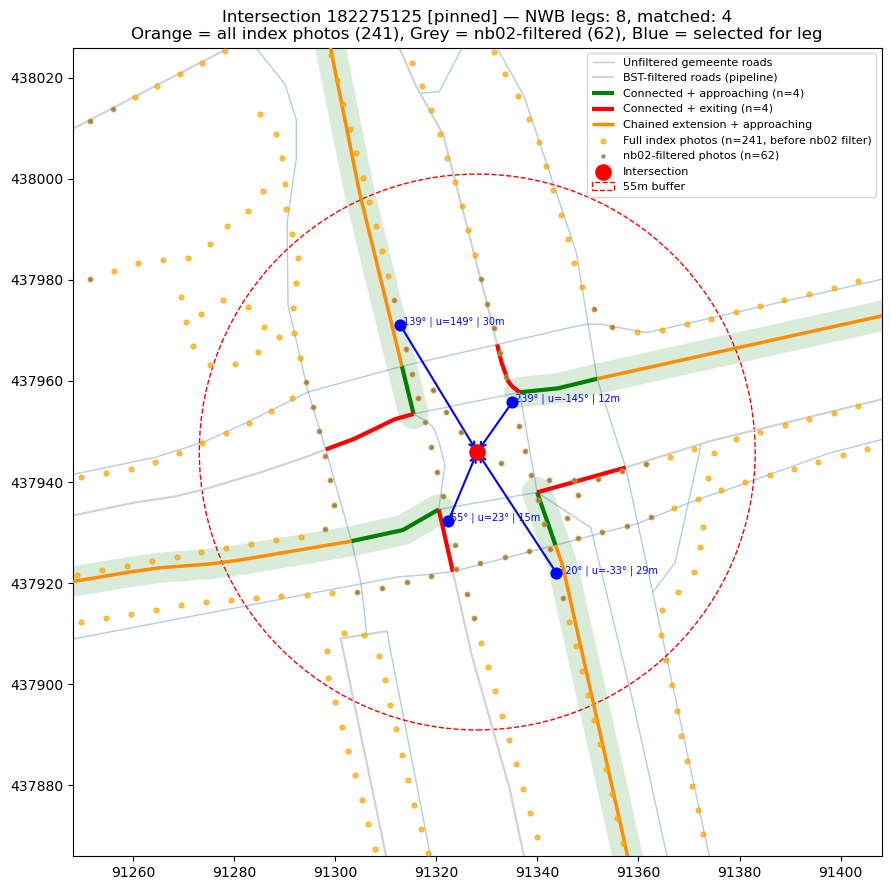

Intersection 182275125 [pinned] — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
        54.7       65_00393          14.7   22.7
       238.6        4_00422          12.1 -144.9
       320.0        4_00415          28.6  -33.2
       138.7       65_00385          29.5  148.7



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


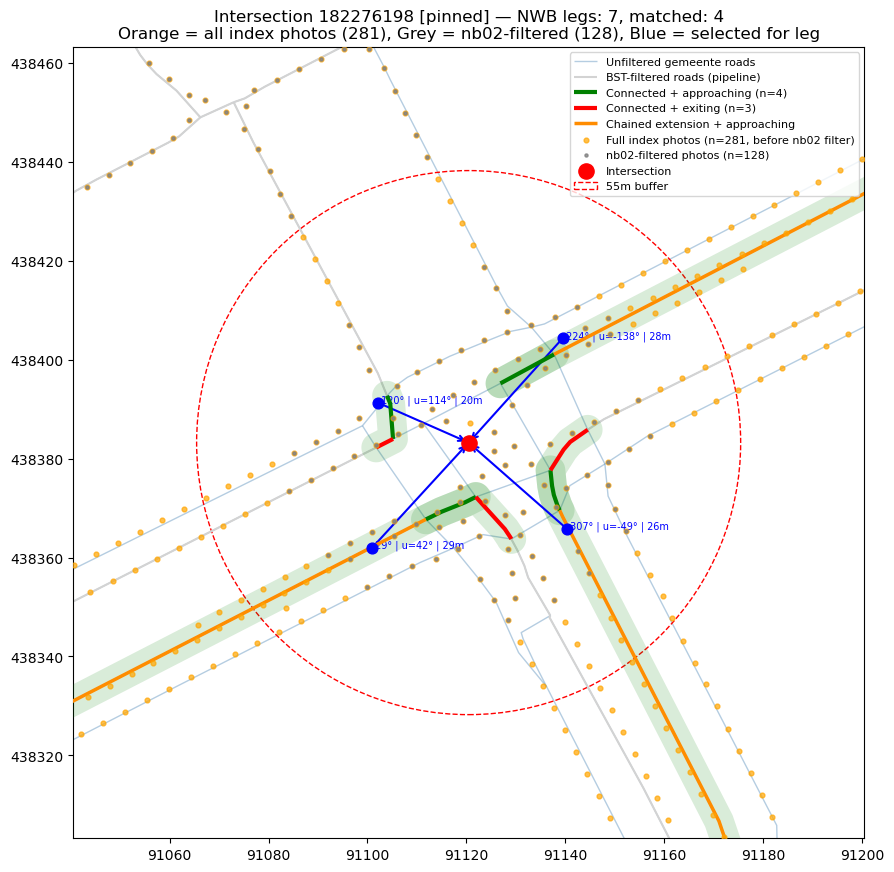

Intersection 182276198 [pinned] — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       119.9       70_03090          19.9  113.8
       306.6        4_00513          26.4  -48.7
       224.1       70_02434          28.4 -138.0
        29.1       65_00291          28.8   42.5



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


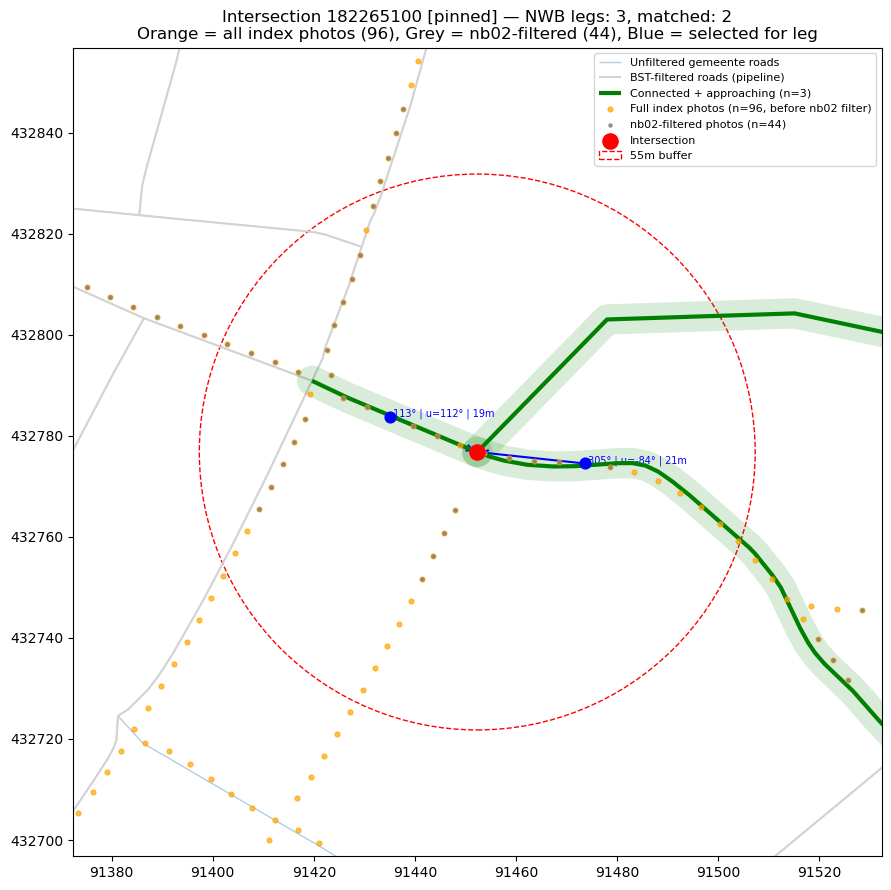

Intersection 182265100 [pinned] — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       304.7      367_00906          21.4  -83.9
       113.3      367_00898          18.6  112.1



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


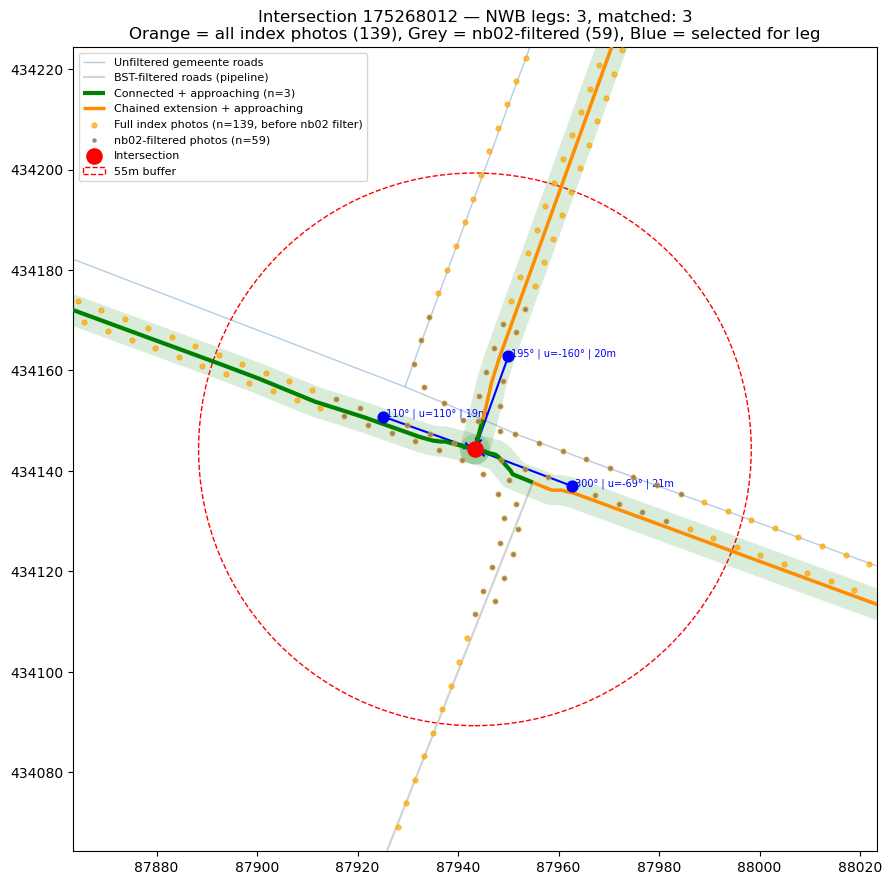

Intersection 175268012 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       194.7      364_03023          19.7 -160.3
       110.0      364_02717          19.4  109.6
       299.8      364_02709          20.6  -69.3



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


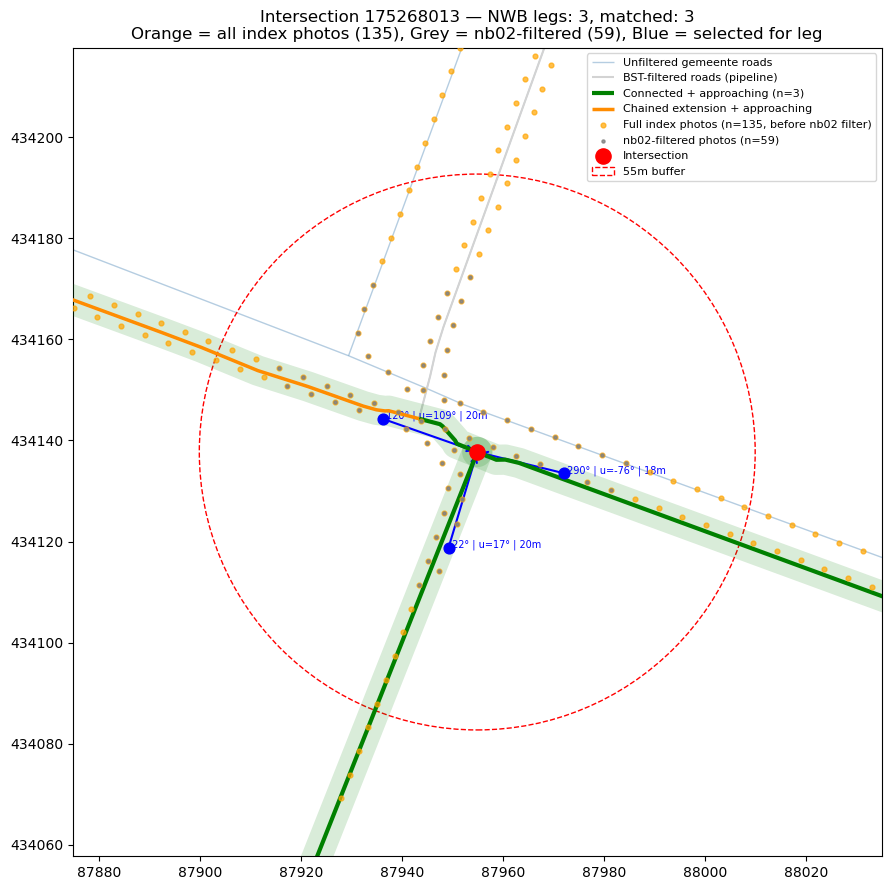

Intersection 175268013 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       119.8      364_02986          19.8  109.4
        21.6      364_03014          19.8   16.7
       289.7      364_02707          17.6  -76.2



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


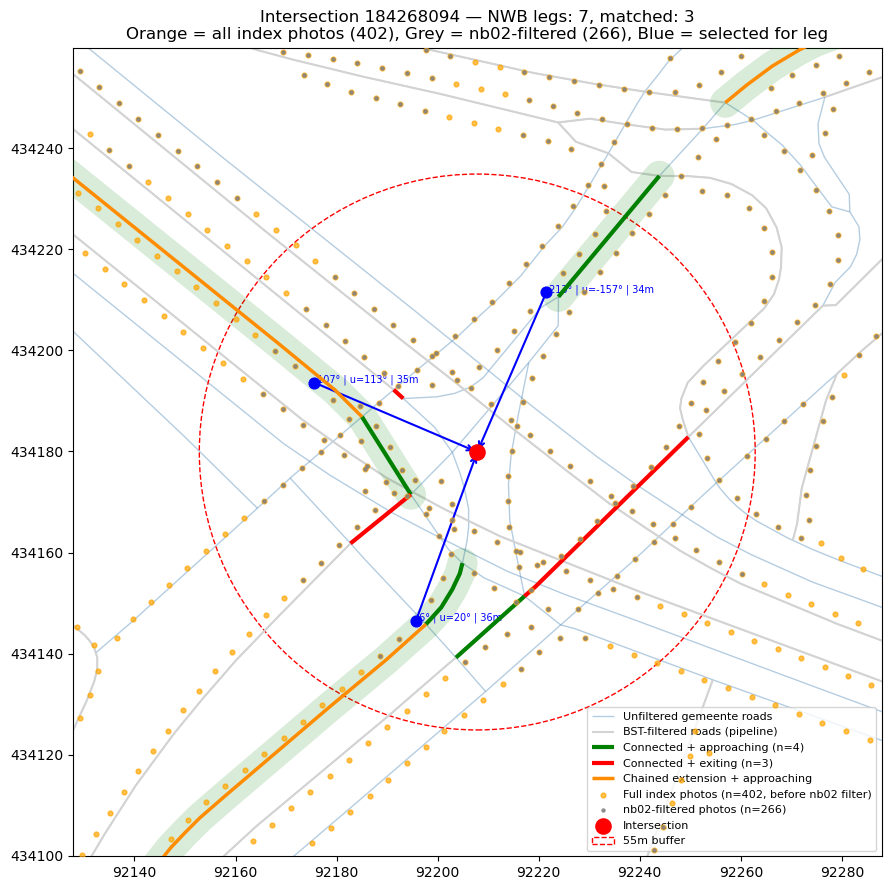

Intersection 184268094 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       213.4      561_02504          34.4 -156.6
       107.0      553_01042          35.1  113.1
         5.9      386_00348          35.5   20.0



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


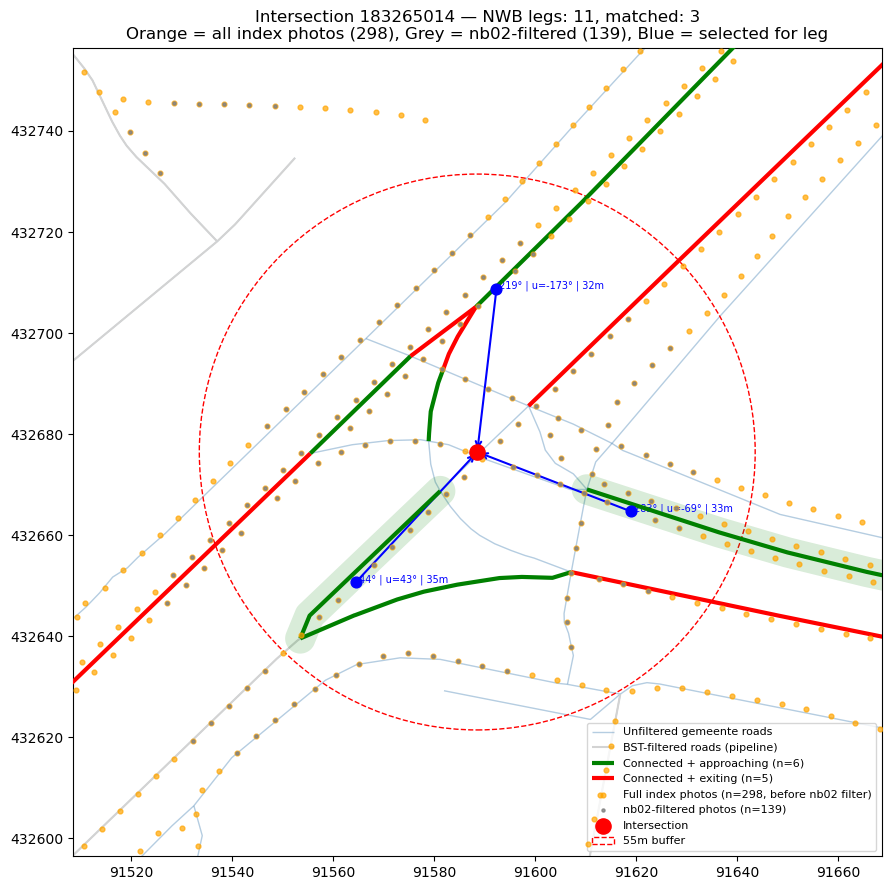

Intersection 183265014 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       218.7      387_00076          32.5 -173.3
       283.3      373_00473          32.6  -68.9
        43.5      369_00758          35.3   43.0



C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\2640330640.py:189: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


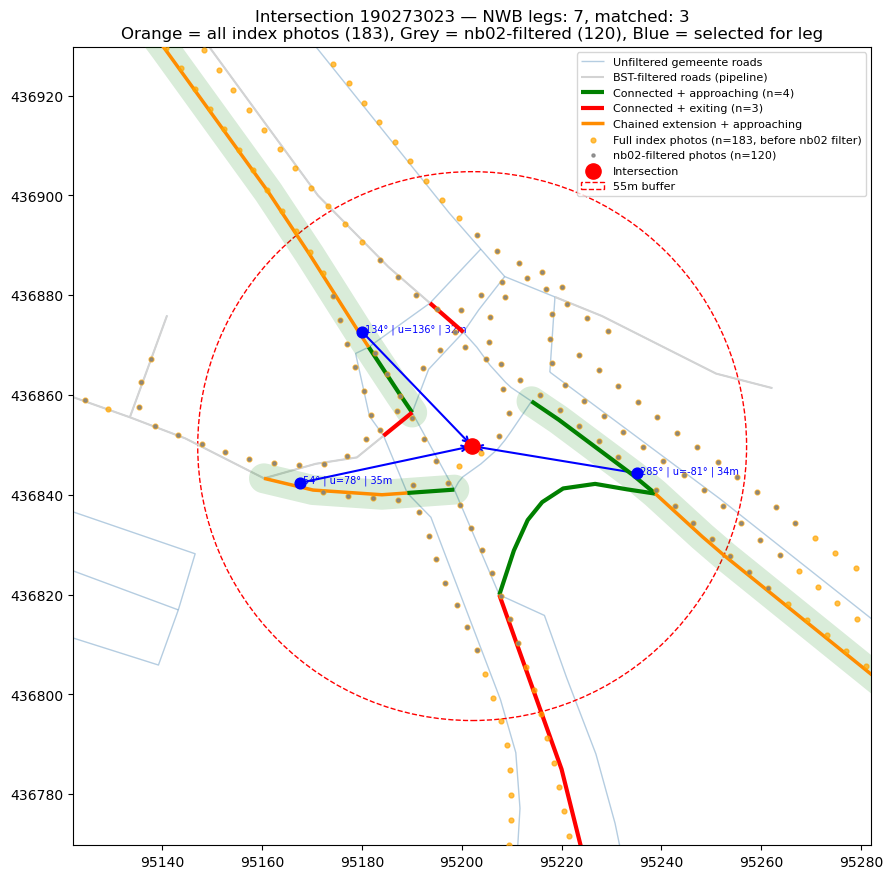

Intersection 190273023 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       133.7       32_09758          31.9  136.1
       284.6       12_01474          33.5  -80.6
        54.2       32_08474          35.2   78.0



In [23]:
import geopandas as gpd

# Always show these intersections first:
#   182275125 - the complex one used for initial debugging
#   182276198 - large multi-carriageway intersection (complex, many legs)
#   182265100 - curved approach legs, used to identify the chaining issue
# Then append up to 5 well-covered intersections as extra examples.
PINNED_IDS = [182275125, 182276198, 182265100]

well_covered = coverage[coverage["matched_legs"] >= 3].index

# Candidates: well-covered intersections not already pinned, with intersection metadata
wc_candidates = intersections.loc[
    [i for i in well_covered if i not in PINNED_IDS and i in intersections.index]
]

# 2 simplest (smallest diameter — singletons first)
simple_ids  = list(wc_candidates.nsmallest(2, "diameter_m").index)

# Up to 3 most complex (largest diameter), not already chosen as simple
complex_ids = list(
    wc_candidates[~wc_candidates.index.isin(simple_ids)]
    .nlargest(3, "diameter_m").index
)

extra_ids = simple_ids + complex_ids

# Only keep IDs that are actually in the processed set (in case N_INTERSECTIONS cut them off)
all_show_ids = [i for i in PINNED_IDS + extra_ids if i in intersections.index]

# --- Load full image index for the "unfiltered photos" comparison layer ---
# The grey dots in the plot come from selected_photos_{IMAGE_MODE}.csv — already
# filtered by notebook 02 to photos near intersections. The orange dots show ALL
# photos from image_index.csv before that filter, so you can see what nb02 cut.
# Reuse full_df if section 7 has already been run; otherwise load it now.
try:
    _full_index = full_df  # already loaded in section 7
    print(f"Using full_df from section 7 ({len(_full_index):,} photos total)")
except NameError:
    _full_index = pd.read_csv(INDEX_PATH, usecols=["image_id", "x", "y"])
    print(f"Loaded full index on-the-fly ({len(_full_index):,} photos total)")

for example_id in all_show_ids:
    inter_row        = intersections.loc[example_id]
    inter_x, inter_y = inter_row.geometry.x, inter_row.geometry.y
    matched_legs_example = result_df[result_df["intersection_id"] == example_id]

    # Photos within VIZ_RADIUS of the intersection — pre-filtered by notebook 02
    nearby_mask = (
        (np.abs(photos_gdf["x"] - inter_x) < VIZ_RADIUS) &
        (np.abs(photos_gdf["y"] - inter_y) < VIZ_RADIUS)
    )
    nearby_photos = photos_gdf[nearby_mask]

    # All photos within VIZ_RADIUS from the full unfiltered image index
    full_nearby_mask = (
        (np.abs(_full_index["x"] - inter_x) < VIZ_RADIUS) &
        (np.abs(_full_index["y"] - inter_y) < VIZ_RADIUS)
    )
    full_nearby = _full_index[full_nearby_mask]

    # Bounding box mask for nearby road segments
    def nearby_wvk(gdf):
        b = gdf.geometry.bounds
        return gdf[
            (b["minx"] < inter_x + VIZ_RADIUS) & (b["maxx"] > inter_x - VIZ_RADIUS) &
            (b["miny"] < inter_y + VIZ_RADIUS) & (b["maxy"] > inter_y - VIZ_RADIUS)
        ]

    nearby_unfiltered = nearby_wvk(wegvakken_unfiltered)
    nearby_filtered   = nearby_wvk(wegvakken)

    # Directly connected segments (1st hop) with approach status merged in
    connected = wegvakken[
        (wegvakken["JTE_ID_BEG"] == example_id) |
        (wegvakken["JTE_ID_END"] == example_id)
    ]
    jte_status = (
        conn_approach[conn_approach["JTE_ID"] == example_id]
        [["WVK_ID", "approach_status"]]
        .drop_duplicates("WVK_ID")
    )
    connected_cl = connected.merge(jte_status, on="WVK_ID", how="left")
    connected_cl["approach_status"] = connected_cl["approach_status"].fillna("unknown")

    # Split directly connected segments by approach status for separate colouring
    conn_approaching = connected_cl[connected_cl["approach_status"] != "exiting"]
    conn_exiting     = connected_cl[connected_cl["approach_status"] == "exiting"]

    # For chained extensions, determine each leg's approach status by looking up
    # the directly connected segment that links example_id to neighbor_jte_id.
    # Chained geoms for approaching legs -> orange; for exiting legs -> light blue.
    # Buffers are only collected for approaching legs.
    legs_for_inter = legs_df[legs_df["intersection_id"] == example_id]

    orange_geoms    = []  # chained extension for an approaching leg
    lightblue_geoms = []  # chained extension for an exiting leg
    approaching_buffers = []

    for _, leg_row in legs_for_inter.iterrows():
        nbr_jte = leg_row["neighbor_jte_id"]

        # Find the WVK_ID(s) of the segment connecting example_id to neighbor_jte_id
        leg_wvk_ids = wegvakken[
            ((wegvakken["JTE_ID_BEG"] == example_id) & (wegvakken["JTE_ID_END"] == nbr_jte)) |
            ((wegvakken["JTE_ID_END"] == example_id) & (wegvakken["JTE_ID_BEG"] == nbr_jte))
        ]["WVK_ID"]

        # Look up approach status; default to 'unknown' if not found
        status_rows = jte_status[jte_status["WVK_ID"].isin(leg_wvk_ids)]
        leg_status  = status_rows.iloc[0]["approach_status"] if len(status_rows) > 0 else "unknown"
        is_approaching = leg_status != "exiting"

        # Collect buffer only for approaching legs
        if is_approaching:
            approaching_buffers.append(leg_row["road_buffer_geom"])

        # Collect chained geoms (those not already shown as directly connected)
        for geom in leg_row["chained_geoms"]:
            if not any(geom.equals(connected.geometry.iloc[i]) for i in range(len(connected))):
                if is_approaching:
                    orange_geoms.append(geom)
                else:
                    lightblue_geoms.append(geom)

    fig, ax = plt.subplots(figsize=(9, 9))

    # Layer 1: all gemeente roads before BST filter -- steelblue background context
    nearby_unfiltered.plot(ax=ax, color="steelblue", linewidth=1, alpha=0.4, zorder=1,
                           label="Unfiltered gemeente roads")
    # Layer 2: BST-filtered pipeline roads -- light grey
    nearby_filtered.plot(ax=ax, color="lightgrey", linewidth=1.5, zorder=2,
                         label="BST-filtered roads (pipeline)")
    # Layer 3: per-leg buffer polygons -- only for approaching legs (green tint)
    if approaching_buffers:
        buffers_gdf = gpd.GeoDataFrame(geometry=approaching_buffers, crs=CRS_RD)
        buffers_gdf.plot(ax=ax, color="green", alpha=0.15, zorder=3,
                         label=f"Approaching leg buffers ({ROAD_BUFFER_M}m)")
    # Layer 4a: directly connected + approaching -- solid green
    if len(conn_approaching) > 0:
        conn_approaching.plot(ax=ax, color="green", linewidth=3, zorder=4,
                              label=f"Connected + approaching (n={len(conn_approaching)})")
    # Layer 4b: directly connected + exiting -- solid red
    if len(conn_exiting) > 0:
        conn_exiting.plot(ax=ax, color="red", linewidth=3, zorder=4,
                          label=f"Connected + exiting (n={len(conn_exiting)})")
    # Layer 5a: chained extensions for approaching legs -- orange
    if orange_geoms:
        orange_gdf = gpd.GeoDataFrame(geometry=orange_geoms, crs=CRS_RD)
        orange_gdf.plot(ax=ax, color="darkorange", linewidth=2.5, zorder=5,
                        label=f"Chained extension + approaching")
    # Layer 5b: chained extensions for exiting legs -- light blue
    if lightblue_geoms:
        lb_gdf = gpd.GeoDataFrame(geometry=lightblue_geoms, crs=CRS_RD)
        lb_gdf.plot(ax=ax, color="lightblue", linewidth=2.5, zorder=5,
                    label=f"Chained extension + exiting")
    # Layer 6: ALL photos from full image_index (before notebook 02 filter) -- orange dots.
    # These show every photo the car drove past here.
    # If an orange dot has no grey dot on top, notebook 02 cut it from the pre-filter.
    if len(full_nearby) > 0:
        ax.scatter(full_nearby["x"], full_nearby["y"],
                   color="orange", s=12, alpha=0.7, zorder=6,
                   label=f"Full index photos (n={len(full_nearby)}, before nb02 filter)")
    # Layer 7: pre-filtered photos from selected_photos_{IMAGE_MODE}.csv -- grey dots.
    # These survived notebook 02's distance buffer; a grey dot overlaps an orange one below.
    # Missing grey = photo was cut by nb02.
    nearby_photos.plot(ax=ax, color="grey", markersize=5, alpha=0.8, zorder=7,
                       label=f"nb02-filtered photos (n={len(nearby_photos)})")
    # Layer 8: intersection centre -- red dot
    ax.scatter(inter_x, inter_y, color="red", s=120, zorder=8, label="Intersection")
    # Layer 9: matched leg photos -- blue dots with arrows and labels
    for _, leg in matched_legs_example.iterrows():
        ax.scatter(leg["photo_x"], leg["photo_y"], color="blue", s=60, zorder=9)
        ax.annotate("", xy=(inter_x, inter_y), xytext=(leg["photo_x"], leg["photo_y"]),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
        ax.text(leg["photo_x"], leg["photo_y"],
                f" {leg['leg_bearing']:.0f}° | u={leg['u_deg']:.0f}° | {leg['photo_dist_m']:.0f}m",
                fontsize=7, color="blue")

    # 55m buffer circle -- outer edge of photo selection zone
    circle = plt.Circle((inter_x, inter_y), 55, color="red", fill=False,
                         linestyle="--", linewidth=1, label="55m buffer")
    ax.add_patch(circle)

    tag = " [pinned]" if example_id in PINNED_IDS else ""
    ax.set_xlim(inter_x - VIZ_RADIUS, inter_x + VIZ_RADIUS)
    ax.set_ylim(inter_y - VIZ_RADIUS, inter_y + VIZ_RADIUS)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    ax.set_title(
        f"Intersection {example_id}{tag} — "
        f"NWB legs: {len(connected)}, matched: {len(matched_legs_example)}\n"
        f"Orange = all index photos ({len(full_nearby)}), "
        f"Grey = nb02-filtered ({len(nearby_photos)}), "
        f"Blue = selected for leg"
    )
    plt.tight_layout()
    plt.show()

    print(f"Intersection {example_id}{tag} — matched photos:")
    print(matched_legs_example[["leg_bearing", "photo_filename", "photo_dist_m", "u_deg"]].to_string(index=False))
    print()

## 6. Export result

## 6a. Traffic intensity per approach leg

Adds `intensity_wvk` — the total daily traffic flow (vehicles/day) on the specific
road segment the photo was taken on. Unlike the intersection-level `intensity_sum`
(notebook 03), this is **per leg**: each approach can have a different intensity.

**Why per leg?** A T-junction may have a quiet residential street on one side and a
busy arterial on another. The intensity of the specific approach is more informative
for the safety assessment than the total over all legs.

**Source:** Fileradar AI model 2024 (`INTWERKP50`, weekday annual average).
The Rotterdam-only cache `intensiteiten_rotterdam.csv` is read here — it must exist
(run notebook 03 with `USE_INTENSITY=True` first).

**Join strategy:**
1. `legs_df.neighbor_jte_id` (junction at the far end of the approach) + `intersection_id`
   → match to `WVK_ID` in `wegvakken` via `JTE_ID_BEG` / `JTE_ID_END`
2. Look up `INTWERKP50` for that `WVK_ID` (H+T rows summed = total two-way flow)

**Output columns added to `leg_photo_selection.csv`:**
- `neighbor_jte_id` — far-end junction ID (identifies which road the photo is on)
- `WVK_ID` — NWB road segment ID of the approach
- `intensity_wvk` — vehicles/day on that segment (H+T combined)

In [24]:
if USE_INTENSITY:
    if not os.path.exists(INTENSITY_ROT_FILE):
        raise FileNotFoundError(
            f"Intensity cache not found: {INTENSITY_ROT_FILE}\n"
            "Run notebook 03 first with USE_INTENSITY=True to generate the cache,\n"
            "or set USE_INTENSITY=False to skip this step."
        )

    # Load the Rotterdam intensity cache — one row per (WVK_ID, RIJRICHTNG).
    # This cache was created by notebook 03 from the full Zuid-Holland shapefile.
    int_cache = pd.read_csv(INTENSITY_ROT_FILE)
    int_cache = int_cache[int_cache["METHODE"] != "Geen"]   # drop sentinel -1 rows
    int_cache["WVK_ID_int"] = int_cache["WVK_ID"].astype(int)

    # Build total intensity per WVK_ID: sum INTWERKP50 across H and T rows.
    # For one-way roads (single row) this is the directional flow.
    # For two-way roads (two rows) this is the full bidirectional flow.
    wvk_intensity = (
        int_cache.groupby("WVK_ID_int")["INTWERKP50"]
        .sum()
        .to_dict()
    )
    print(f"WVK_IDs with valid intensity: {len(wvk_intensity):,}")

    # Add neighbor_jte_id from legs_df to result_df.
    # legs_df.neighbor_jte_id is the junction at the far end of the approach segment —
    # together with intersection_id it uniquely identifies which WVK connects this leg.
    result_df = result_df.merge(
        legs_df[["intersection_id", "leg_bearing", "neighbor_jte_id"]].drop_duplicates(),
        on=["intersection_id", "leg_bearing"],
        how="left"
    )

    # Find the WVK_ID for each leg by matching the junction pair in wegvakken.
    # A leg connects neighbor_jte_id → intersection_id; the segment in wegvakken
    # has one junction as JTE_ID_BEG and the other as JTE_ID_END.
    wvk_attrs = wegvakken[["WVK_ID", "JTE_ID_BEG", "JTE_ID_END"]].copy()

    # Case H: neighbor is at BEG, intersection is at END (H direction: BEG→END)
    match_h = result_df[["intersection_id", "leg_bearing", "neighbor_jte_id"]].merge(
        wvk_attrs.rename(columns={"JTE_ID_BEG": "neighbor_jte_id",
                                   "JTE_ID_END": "intersection_id"}),
        on=["intersection_id", "neighbor_jte_id"],
        how="inner"
    )

    # Case T: neighbor is at END, intersection is at BEG (T direction: END→BEG)
    match_t = result_df[["intersection_id", "leg_bearing", "neighbor_jte_id"]].merge(
        wvk_attrs.rename(columns={"JTE_ID_END": "neighbor_jte_id",
                                   "JTE_ID_BEG": "intersection_id"}),
        on=["intersection_id", "neighbor_jte_id"],
        how="inner"
    )

    # Combine both match directions, keep one WVK_ID per (intersection_id, leg_bearing).
    # H matches take priority since get_leg_bearings() already kept approaching H lanes.
    leg_to_wvk = (
        pd.concat([match_h, match_t])
        .drop_duplicates(subset=["intersection_id", "leg_bearing"])
        [["intersection_id", "leg_bearing", "WVK_ID"]]
    )

    result_df = result_df.merge(leg_to_wvk, on=["intersection_id", "leg_bearing"], how="left")

    # Look up intensity for each approach segment.
    # NaN is used when the WVK_ID is missing (no match) or not in the intensity data.
    result_df["intensity_wvk"] = result_df["WVK_ID"].map(
        lambda wid: wvk_intensity.get(int(wid), np.nan) if pd.notna(wid) else np.nan
    )

    n_matched = result_df["intensity_wvk"].notna().sum()
    print(f"Legs with intensity_wvk  : {n_matched:,} / {len(result_df):,}  ({n_matched/len(result_df)*100:.1f}%)")
    print(f"\nintensity_wvk stats (vehicles/day, H+T sum for this approach segment):")
    print(result_df["intensity_wvk"].describe().round(0))

else:
    # Add NaN columns so the output schema stays consistent regardless of the toggle
    result_df["neighbor_jte_id"] = np.nan
    result_df["WVK_ID"]          = np.nan
    result_df["intensity_wvk"]   = np.nan
    print("Traffic intensity skipped (USE_INTENSITY = False).")

C:\Users\Thijs\AppData\Local\Temp\ipykernel_19552\3365063175.py:11: DtypeWarning: Columns (0: WEGNUMMER, 1: WEGNR_HMP) have mixed types. Specify dtype option on import or set low_memory=False.
  int_cache = pd.read_csv(INTENSITY_ROT_FILE)


WVK_IDs with valid intensity: 22,162
Legs with intensity_wvk  : 11,967 / 12,677  (94.4%)

intensity_wvk stats (vehicles/day, H+T sum for this approach segment):
count    11967.0
mean      2108.0
std       3252.0
min          0.0
25%        300.0
50%        650.0
75%       2350.0
max      28550.0
Name: intensity_wvk, dtype: float64


In [25]:
# Save the pipeline output: one best-matched photo per leg.
# This is consumed by notebooks 05, 06, and 07 -- schema must stay stable.
result_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(result_df):,} leg-photo assignments to:")
print(f"  {OUTPUT_CSV}")

# Save the CV export list: top-N ranked candidates per leg (before bearing dedup).
# Each row has a candidate_rank column (1=best, 2=runner-up, ...) so downstream
# code can filter to any desired depth.
candidates_df = pd.DataFrame(all_candidates)
candidates_df.to_csv(CANDIDATES_CSV, index=False)
print(f"\nSaved {len(candidates_df):,} candidate rows (top-{TOP_N_CANDIDATES} per leg) to:")
print(f"  {CANDIDATES_CSV}")
print(f"  rank 1 : {(candidates_df['candidate_rank']==1).sum():,} legs")
print(f"  rank 2 : {(candidates_df['candidate_rank']==2).sum():,} legs")
print(f"  rank 3+: {(candidates_df['candidate_rank']>=3).sum():,} legs")

result_df.head()

Saved 12,677 leg-photo assignments to:
  C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\leg_photo_selection_directional.csv

Saved 37,194 candidate rows (top-3 per leg) to:
  C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\leg_photo_candidates_directional.csv
  rank 1 : 12,709 legs
  rank 2 : 12,410 legs
  rank 3+: 12,075 legs


,intersection_id,leg_bearing,photo_filename,photo_dist_m,u_deg,photo_x,photo_y,photo_bearing_to_inter,candidate_rank,is_panorama,...,filepath_right,filepath_back,filepath_left,requires_stitch,stitch_left_filepath,stitch_right_filepath,stitch_inter_col_frac,neighbor_jte_id,WVK_ID,intensity_wvk
0,175268012,194.7,364_03023,19.7,-160.3,87950.010,434162.853,199.7,1,False,...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,True,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,0.5354,600181490,600723084,1000.0
1,175268012,110.0,364_02717,19.4,109.6,87925.094,434150.823,109.6,1,False,...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,False,NaN,NaN,NaN,600181773,600722714,750.0
2,175268012,299.8,364_02709,20.6,-69.3,87962.624,434137.018,290.7,1,False,...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,False,NaN,NaN,NaN,175268013,175268002,1650.0
3,175268013,119.8,364_02986,19.8,109.4,87936.207,434144.273,109.4,1,False,...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,False,NaN,NaN,NaN,175268012,175268002,1650.0
4,175268013,21.6,364_03014,19.8,16.7,87949.209,434118.793,16.7,1,False,...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,True,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,88196ba233fffff/89196ba2323ffff/8a196ba23217ff...,0.9831,175268006,175267002,200.0


## 7. Coverage check — photos in image_index.csv missing from the pre-filter

Notebook 02 pre-filtered the full `image_index.csv` to photos within the per-intersection
buffer and wrote `selected_photos_{IMAGE_MODE}.csv`. This section checks whether any
photos that fall inside that distance band were accidentally dropped (false drops).

Uses a KDTree on intersection coordinates for fast nearest-neighbour distance
lookup across all ~617k index rows.

In [26]:
from scipy.spatial import KDTree

# Load the full image_index.csv to check what notebook 02 started with.
# INDEX_PATH auto-detects HDD vs local (set in config cell) so both notebooks
# always see the same source data regardless of whether the HDD is connected.
full_df = pd.read_csv(INDEX_PATH, usecols=["image_id", "x", "y"])

print(f"Full image index loaded from: {INDEX_PATH}")
print(f"Total photos in image_index.csv:              {len(full_df):,}")
print(f"Photos in selected_photos_{IMAGE_MODE}.csv:   {len(selected):,}")

# --- Step 1: identify photos in the index not in the pre-filtered CSV ---
selected_ids = set(selected["image_id"])
missing = full_df[~full_df["image_id"].isin(selected_ids)].copy()

print(f"Photos in index but NOT in selected:          {len(missing):,}")
print(f"  ({len(missing) / len(full_df) * 100:.1f}% of all photos were not pre-selected)")

# --- Step 2: fast nearest-intersection distance for every missing photo ---
inter_xy = np.column_stack([
    intersections.geometry.x.values,
    intersections.geometry.y.values,
])
tree = KDTree(inter_xy)

# Coordinates come directly from the x/y columns — already in RD New, no geometry needed
missing_xy = np.column_stack([missing["x"].values, missing["y"].values])

print("\nQuerying nearest-intersection distance for all missing photos...")
dists, nearest_idx = tree.query(missing_xy, k=1)

# --- Step 3: check for false drops ---
# A false drop is a photo within notebook 04's per-intersection search range
# that is absent from the pre-filtered CSV — meaning this notebook cannot find it.
if "max_dist_m" in intersections.columns:
    nearest_max_dist = intersections["max_dist_m"].values[nearest_idx]
else:
    nearest_max_dist = MAX_DIST  # fallback if intersections file lacks max_dist_m

in_range      = (dists >= MIN_DIST) & (dists <= nearest_max_dist)
n_false_drops = in_range.sum()

print(f"\nMissing photos within notebook 04's per-intersection search range: {n_false_drops:,}")

if n_false_drops == 0:
    print("\nResult: no false drops detected.")
    print("Every photo this notebook could use is present in the pre-filtered CSV.")
else:
    false_drops = missing[in_range].copy()
    false_drops["dist_to_nearest_inter"] = dists[in_range]
    false_drops["nearest_inter_id"]      = intersections.index[nearest_idx[in_range]]
    if "max_dist_m" in intersections.columns:
        false_drops["nearest_max_dist_m"] = nearest_max_dist[in_range]

    print(f"\nWARNING: {n_false_drops:,} photos are within the per-intersection search range")
    print(f"but absent from the pre-filtered CSV — notebook 04 cannot find them.")
    print(f"\nDistance distribution of false drops (metres):")
    print(false_drops["dist_to_nearest_inter"].describe().round(1))
    print(f"\nSample rows:")
    print(false_drops[["image_id", "dist_to_nearest_inter", "nearest_inter_id"]].head(10).to_string(index=False))

# --- Step 4: intersection size distribution ---
if "max_dist_m" in intersections.columns:
    print(f"\n--- Step 4: intersection size distribution ---")
    print(f"max_dist_m range: {intersections['max_dist_m'].min():.1f}–{intersections['max_dist_m'].max():.1f}m")
    oversized = intersections[intersections["max_dist_m"] > 55]
    if len(oversized) > 0:
        oversized_legs = legs_df[legs_df["intersection_id"].isin(oversized.index)]
        unmatched_count = (
            oversized_legs
            .merge(
                result_df[["intersection_id", "leg_bearing"]].assign(_matched=True),
                on=["intersection_id", "leg_bearing"],
                how="left",
            )["_matched"]
            .isna()
            .sum()
        )
        print(f"Intersections with max_dist_m > 55m: {len(oversized):,} "
              f"(max: {oversized['max_dist_m'].max():.1f}m)")
        print(f"Affected legs: {len(oversized_legs):,} — unmatched among those: {unmatched_count:,}")
        if n_false_drops == 0:
            print("Notebook 02 covers these — no action needed.")
    else:
        print("All intersections have max_dist_m <= 55m.")

Full image index loaded from: D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv
Total photos in image_index.csv:              617,579
Photos in selected_photos_directional.csv:   101,609
Photos in index but NOT in selected:          515,970
  (83.5% of all photos were not pre-selected)

Querying nearest-intersection distance for all missing photos...

Missing photos within notebook 04's per-intersection search range: 0

Result: no false drops detected.
Every photo this notebook could use is present in the pre-filtered CSV.

--- Step 4: intersection size distribution ---
max_dist_m range: 25.0–40.9m
All intersections have max_dist_m <= 55m.
